### Завдання 1
Потрібно проаналізувати взаємозв'язок між користувачами, сесіями та виручкою за днями. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
* Сформуйте таблицю мінімум на 30 днів із колонками "date", "users", "sessions", "revenue".
* Розрахуйте кореляційну матрицю для цих метрик.
* Побудуйте діаграми розсіювання для пар: users-sessions, users-revenue, sessions-revenue.
* Побудуйте лінійний графік "revenue" за датами.
* Виведіть матрицю та всі графіки.

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [73]:
np.random.seed(42)

dates = pd.date_range(start='2024-01-01', periods=30)

users = np.random.randint(100, 500, size=30)
sessions = users + np.random.randint(0, 200, size=30)  
revenue = users * np.random.uniform(1.5, 3.0, size=30) + np.random.randint(0, 200, size=30)

df = pd.DataFrame({
    'date': dates,
    'users': users,
    'sessions': sessions,
    'revenue': revenue
})

print("Таблиця даних:")
print(df.head())



Таблиця даних:
        date  users  sessions      revenue
0 2024-01-01    202       290   464.030716
1 2024-01-02    448       496  1201.153085
2 2024-01-03    370       428   901.548145
3 2024-01-04    206       375   653.457228
4 2024-01-05    171       358   428.968034


In [74]:
corr_matrix = df[['users', 'sessions', 'revenue']].corr()

print("\nКореляційна матриця:")
print(corr_matrix)



Кореляційна матриця:
             users  sessions   revenue
users     1.000000  0.846673  0.928266
sessions  0.846673  1.000000  0.723764
revenue   0.928266  0.723764  1.000000


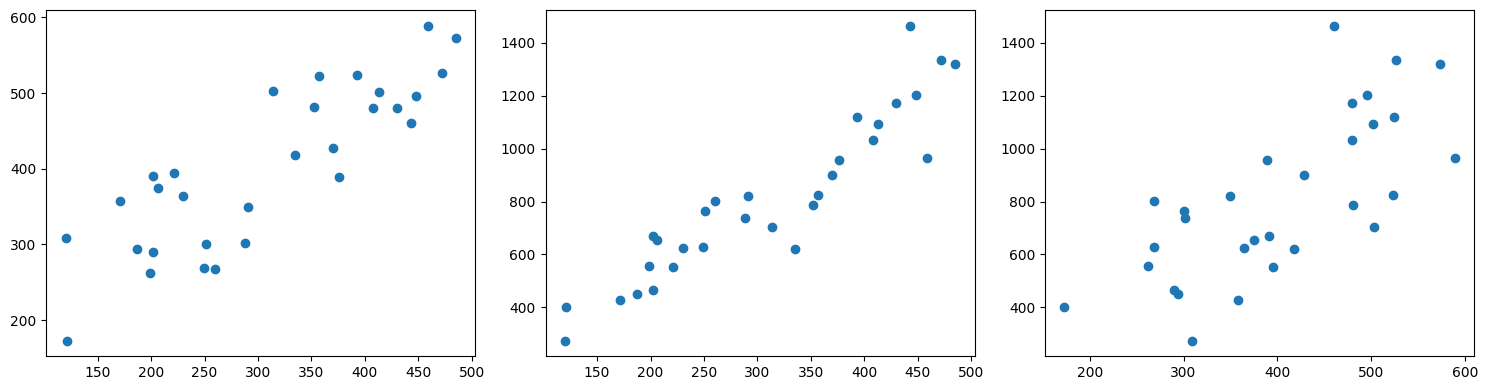

In [75]:
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.scatter(df['users'], df['sessions'])

plt.subplot(1, 3, 2)
plt.scatter(df['users'], df['revenue'])

plt.subplot(1, 3, 3)
plt.scatter(df['sessions'], df['revenue'])


plt.tight_layout()
plt.show()

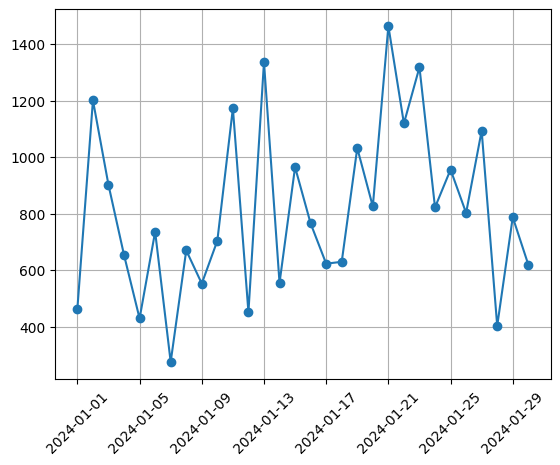

In [76]:
plt.plot(df['date'], df['revenue'], marker='o')
plt.xticks(rotation=45)
plt.grid()

plt.show()

### Завдання 2
Потрібно проаналізувати дані A/B-експерименту та візуалізувати конверсії. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
* Сформуйте таблицю з полями "group" (A або B) і "converted" (0/1) з не менш ніж 100 спостереженнями в кожній групі.
* Розрахуйте конверсію в групах, абсолютну різницю та відносну зміну.
* Побудуйте 95% довірчі інтервали для конверсії в кожній групі.
* Побудуйте стовпчасту діаграму конверсій груп із відображенням довірчих інтервалів.
* Виведіть усі розраховані значення та графік.

In [77]:
np.random.seed(42)

n_A = 120
n_B = 130

conv_A = np.random.binomial(1, 0.10, n_A)
conv_B = np.random.binomial(1, 0.13, n_B)

df = pd.DataFrame({
    'group': ['A'] * n_A + ['B'] * n_B,
    'converted': np.concatenate([conv_A, conv_B])
})

In [78]:
summary = df.groupby('group')['converted'].agg(['mean', 'count'])
summary.columns = ['conversion_rate', 'n']

cr_A = summary.loc['A', 'conversion_rate']
cr_B = summary.loc['B', 'conversion_rate']

abs_diff = cr_B - cr_A
rel_change = abs_diff / cr_A


In [79]:
def ci_95(p, n):
    se = np.sqrt(p * (1 - p) / n)
    margin = 1.96 * se
    return p - margin, p + margin

ci_A = ci_95(cr_A, summary.loc['A', 'n'])
ci_B = ci_95(cr_B, summary.loc['B', 'n'])

# Для графіка (похибки)
errors = [
    [cr_A - ci_A[0], cr_B - ci_B[0]],
    [ci_A[1] - cr_A, ci_B[1] - cr_B]
]

In [80]:
print(summary)

print("\nАбсолютна різниця:", abs_diff)
print("Відносна зміна:", rel_change)

print("\n95% довірчі інтервали:")
print(f"A: {ci_A}")
print(f"B: {ci_B}")

       conversion_rate    n
group                      
A             0.091667  120
B             0.169231  130

Абсолютна різниця: 0.07756410256410258
Відносна зміна: 0.8461538461538464

95% довірчі інтервали:
A: (np.float64(0.04003765709230401), np.float64(0.14329567624102932))
B: (np.float64(0.10477463411102739), np.float64(0.2336869043505111))


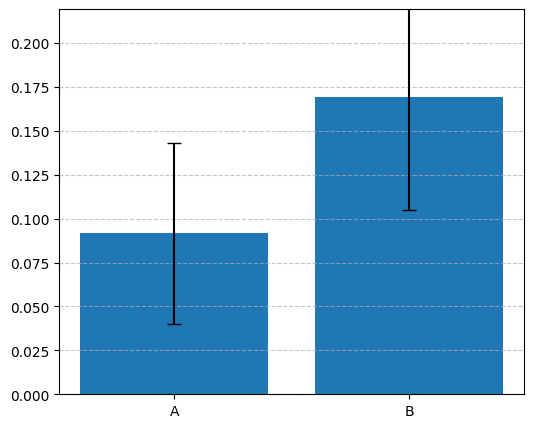

In [81]:
plt.figure(figsize=(6, 5))

groups = ['A', 'B']
values = [cr_A, cr_B]

plt.bar(groups, values, yerr=errors, capsize=5)

plt.ylim(0, max(values) + 0.05)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Завдання 3
Потрібно перевірити дію центральної граничної теореми на прикладі несиметричного розподілу. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
* Згенеруйте генеральну сукупність щонайменше з 50 000 спостережень із несиметричного розподілу.
* Сформуйте кілька підвибірок фіксованого розміру n і для кожної обчисліть середнє.
* Збережіть вибіркові середні та побудуйте їхню гістограму.
* Повторіть процедуру для щонайменше двох різних n і виведіть обидві гістограми.
* Виведіть середнє і стандартне відхилення вибіркових середніх для кожного n.

In [82]:
np.random.seed(42)

population_size = 50000
population = np.random.exponential(scale=1.0, size=population_size)

print("Генеральна сукупність:")
print(f"Mean: {np.mean(population):.4f}")
print(f"Std: {np.std(population):.4f}")


Генеральна сукупність:
Mean: 0.9961
Std: 0.9967


In [83]:
def sample_means(population, sample_size, n_samples=1000):
    means = []
    for _ in range(n_samples):
        sample = np.random.choice(population, size=sample_size)
        means.append(np.mean(sample))
    return np.array(means)


In [84]:
sample_sizes = [5, 30]  # малий і більший n
results = {}


In [85]:
for n in sample_sizes:
    means = sample_means(population, n)
    results[n] = means
    
    print(f"\nДля n = {n}:")
    print(f"Середнє вибіркових середніх: {np.mean(means):.4f}")
    print(f"Стандартне відхилення: {np.std(means):.4f}")


Для n = 5:
Середнє вибіркових середніх: 0.9732
Стандартне відхилення: 0.4346

Для n = 30:
Середнє вибіркових середніх: 0.9948
Стандартне відхилення: 0.1799


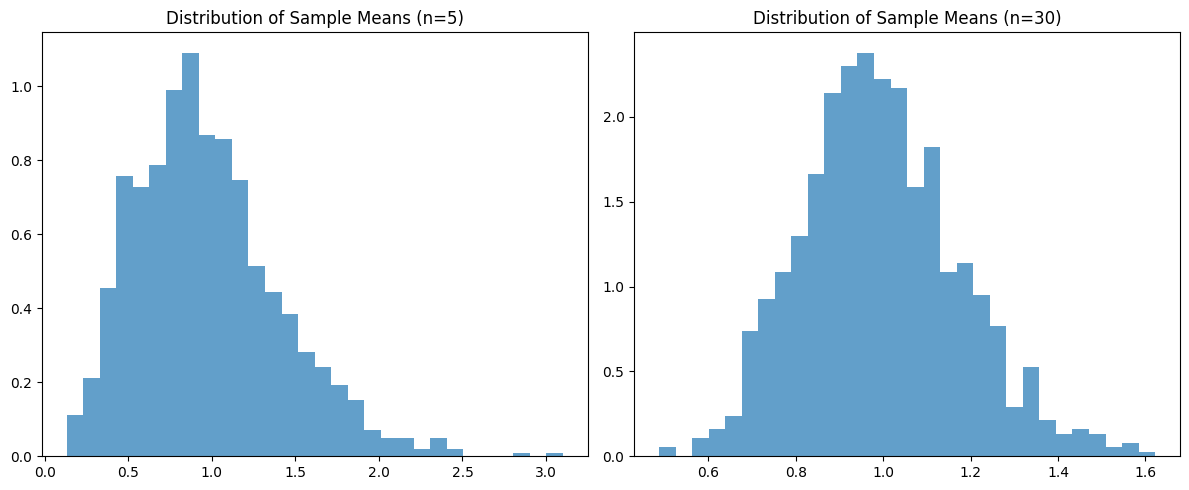

In [93]:
plt.figure(figsize=(12, 5))

for i, n in enumerate(sample_sizes, 1):
    plt.subplot(1, 2, i)
    plt.hist(results[n], bins=30, density=True, alpha=0.7)
    plt.title(f'Distribution of Sample Means (n={n})')

plt.tight_layout()
plt.show()

### Завдання 4
Потрібно проаналізувати часовий ряд продажів і візуалізувати ковзаючі метрики. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
Сформуйте таблицю "date" і "sales" за 90 днів.
* Додайте ковзне середнє і ковзне стандартне відхилення за обраним вікном.
* Побудуйте графік вихідних продажів і графік ковзного середнього на одному полі.
* Побудуйте окремий графік ковзного стандартного відхилення.
* Виведіть таблицю з першими рядками нових стовпців і обидва графіки.

In [94]:
np.random.seed(42)

dates = pd.date_range(start='2024-01-01', periods=90)

trend = np.linspace(50, 100, 90)
noise = np.random.normal(0, 5, 90)
sales = trend + noise

df = pd.DataFrame({
    'date': dates,
    'sales': sales
})


In [95]:
window = 7  

df['rolling_mean'] = df['sales'].rolling(window=window).mean()
df['rolling_std'] = df['sales'].rolling(window=window).std()

# 3. Вивід перших рядків
print("Перші рядки таблиці:")
print(df.head(10))


Перші рядки таблиці:
        date      sales  rolling_mean  rolling_std
0 2024-01-01  52.483571           NaN          NaN
1 2024-01-02  49.870476           NaN          NaN
2 2024-01-03  54.362038           NaN          NaN
3 2024-01-04  59.300543           NaN          NaN
4 2024-01-05  51.076424           NaN          NaN
5 2024-01-06  51.638304           NaN          NaN
6 2024-01-07  61.266851     54.285458     4.357770
7 2024-01-08  57.769758     55.040628     4.450516
8 2024-01-09  52.147010     55.365847     4.077269
9 2024-01-10  57.768980     55.852553     4.140329


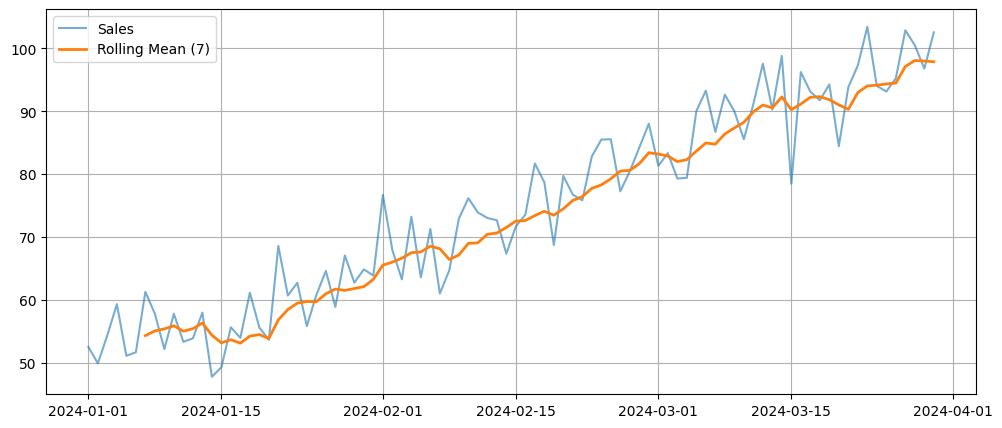

In [102]:
plt.figure(figsize=(12, 5))

plt.plot(df['date'], df['sales'], label='Sales', alpha=0.6)
plt.plot(df['date'], df['rolling_mean'], label='Rolling Mean (7)', linewidth=2)
plt.legend()
plt.grid()

plt.show()

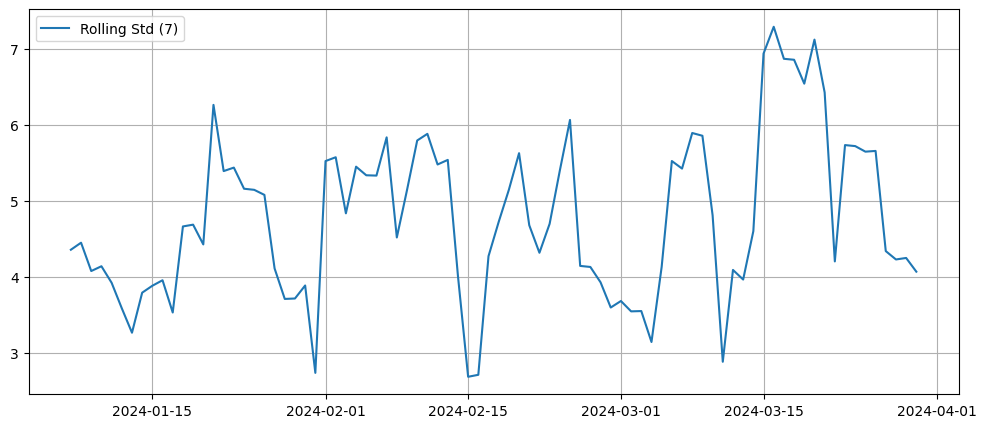

In [103]:
plt.figure(figsize=(12, 5))

plt.plot(df['date'], df['rolling_std'],label='Rolling Std (7)')
plt.legend()
plt.grid()

plt.show()